In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import sys
os.chdir('D:/CEOS') 
sys.path.append(os.path.abspath('D:/CEOS/Modules'))
[sys.path.append(x[0]) for x in os.walk('.')]

import pandas as pd
import tools
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime 
import statsmodels.api as sm

import Algos

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2.0 Materials 

## 2.1 Fiducial Reference Measurements

### Reading in FRM from GROUNDEDEO


FRM corresponded to the GROUNDED EO database of  9382 paired LAI/FAPAR estimates from for 1087 ESUs in 71 sites across three networks within Austrailia  (TERN), Europe (ICOS) and the United States of America (NEON).  Sites are stratified by ecological diversity within their network although some duplication is present at ICOS sites across countries.  

In [118]:
#  Parse FRM data
FRM = tools.parse_FRM(pd.read_csv("D:/CEOS/InputData/all_fiducial_reference_measurements_wai.csv",low_memory=False).rename(columns={'GFIPAR_up':'FAPAR_up','FAPAR':'FAPAR','FAPAR_ci':'FAPAR_ci'}))

Exploratory data analysis indicated 7 forest siteshad Plots that were identified as having default unrealsitically low (<0.25) overestory WAI (Appendix 1).

### Appendix 1 Correction of WAI for Groduned EO Forest Sites 

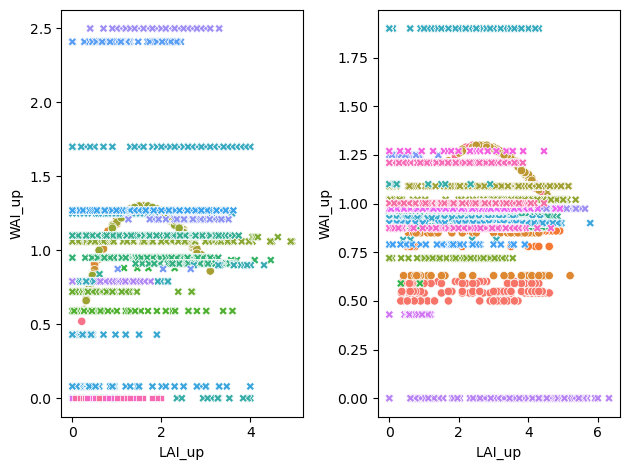

                                           NLCD
Plot                                           
Boyagin_Core                    evergreenForest
Cumberland_Plain_Core           evergreenForest
Gingin_Core                     evergreenForest
Great_Western_Woodlands_Core    evergreenForest
Great_Western_Woodlands_Gimlet  evergreenForest
...                                         ...
SOAP_047                        evergreenForest
SOAP_058                        evergreenForest
Tumbarumba_Core                 evergreenForest
Warra_Core                      evergreenForest
Wombat_Core                     evergreenForest

[62 rows x 1 columns]


In [119]:
fix,axs = plt.subplots(1,2)
sns.scatterplot(FRM[FRM['NLCD_group']=='needleleafForest'],x='LAI_up',y='WAI_up',hue='Site',style='Network',legend=False,ax=axs[0])
sns.scatterplot(FRM[FRM['NLCD_group']=='broadleafForest'],x='LAI_up',y='WAI_up',hue='Site',style='Network',legend=False,ax=axs[1])
plt.tight_layout()
plt.show()
print(FRM[(FRM['NLCD_group']!='nonForest') & (FRM['WAI_up']<0.25)  & (FRM['PAI_up']>1)][['Plot','NLCD']].groupby(['Plot']).min())



Ideally the overstory WAI should be estimated using measurements at each plot as in Brown et al. (2025).  Here, for the purpose of demsontrating our method, the overstory WAI was estimated using data from all other sites with the same NLCD land cover (Appendix 1).

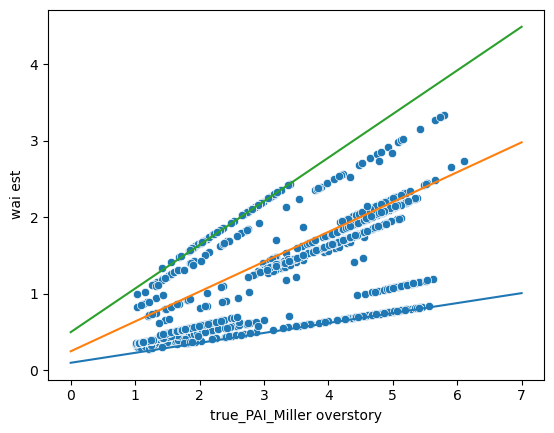

49
49


In [120]:
#Fit a WAI estimator for needleaf forests from NEON data where it was estimated directly from DHPs
df_PAIWAI = pd.read_csv("D:/CEOS/InputData/NEON_2013-22_evergreen_forest_WAI_PAI_estimates.csv")

#Visualize WAI preddictinos
sns.scatterplot(df_PAIWAI,x='true_PAI_Miller overstory',y= 'wai est')

#visual fits to central and extreme values of overstory wai given overstory pai
pai = np.linspace(0,7,100)
plt.plot(pai,0.13*pai+0.1)
plt.plot(pai,0.39*pai+0.25)
plt.plot(pai,0.57*pai+0.5)
plt.show()

index = (FRM['NLCD_group']=='needleleafForest') & (FRM['WAI_up']<0.25)  & (FRM['LAI_up']>1)

#estimate WAI overstory for  sites assuming the range of fitted maximum and minimum curves correspond gto the +/- 2 sigma confidence interval
PAI_up = FRM.loc[index,'PAI_up'].to_numpy() 
PAI = FRM.loc[index,'PAI'].to_numpy()  
LAI_old =  FRM.loc[index ,'LAI'].to_numpy() 
LAI_ci_old =  FRM.loc[index ,'LAI_ci'].to_numpy()  
WAI_up_old = FRM.loc[index,'WAI_up'].to_numpy()  
WAI_up_ci_old = FRM.loc[index,'WAI_up_ci'].to_numpy()  
WAI_up_new = np.minimum(np.maximum(0.39 * PAI_up  + 0.25,0),PAI*0.5)
WAI_up_ci_new = np.minimum(np.maximum((0.57 * PAI_up  + 0.5 - 0.13 * PAI_up  + 0.1)/4  ,0.5),PAI*0.5/4)
print(len(PAI_up))
print(len(FRM.loc[(FRM['NLCD_group']=='needleleafForest') & (FRM['WAI_up']<0.25)  & (FRM['LAI_up']>1) ,'WAI_up'].to_numpy()))
#update new WAI and LAI as well as their CI's
FRM.loc[index ,'WAI_up'] = WAI_up_new
FRM.loc[index,'WAI_up_ci']  =WAI_up_ci_new
FRM.loc[index ,'LAI'] = LAI_old - ( WAI_up_new - WAI_up_old)
FRM.loc[index ,'LAI_ci'] = np.power(np.power(LAI_ci_old,2) - np.power(WAI_up_ci_old,2) + np.power(WAI_up_ci_new,2),0.5)


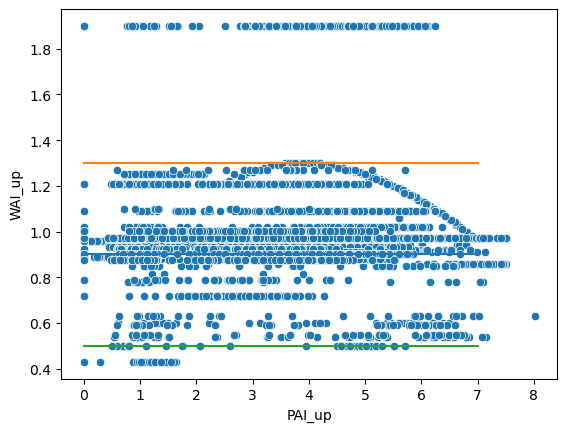

In [121]:
#Fit a WAI estimator for broeadleaf forests from grounded EO data since these data use the minimum observed PAI as WAI directly
df_PAIWAI =FRM[(FRM['NLCD_group']=='broadleafForest') & (FRM['WAI_up']>0.25) ]

#Visualize WAI preddictinos
sns.scatterplot(df_PAIWAI,x='PAI_up',y= 'WAI_up')

#visual fits to central and extreme values of overstory wai given overstory pai
pai = np.linspace(0,7,100)
plt.plot(pai,0.0*pai+0.9)
plt.plot(pai,0.0*pai+1.3)
plt.plot(pai,0.0*pai+0.5)
plt.show()

index = (FRM['NLCD_group']=='broadleafForest') & (FRM['WAI_up']<0.25)  & (FRM['LAI_up']>1)

#estimate WAI overstory for  sites assuming the range of fitted maximum and minimum curves correspond gto the +/- 2 sigma confidence interval
PAI_up = FRM.loc[index,'PAI_up'].to_numpy() 
PAI = FRM.loc[index,'PAI'].to_numpy()  
LAI_old =  FRM.loc[index ,'LAI'].to_numpy() 
LAI_ci_old =  FRM.loc[index ,'LAI_ci'].to_numpy()  
WAI_up_old = FRM.loc[index,'WAI_up'].to_numpy()  
WAI_up_ci_old = FRM.loc[index,'WAI_up_ci'].to_numpy()  
WAI_up_new = np.minimum(np.maximum(0.9,0),PAI*1)
WAI_up_ci_new = np.minimum(np.maximum((1.3 - 0.5)/4 ,0),PAI/4)

#update new WAI and LAI as well as their CI's
FRM.loc[index ,'WAI_up'] = WAI_up_new
FRM.loc[index,'WAI_up_ci']  =WAI_up_ci_new
FRM.loc[index ,'LAI'] = LAI_old - ( WAI_up_new - WAI_up_old)
FRM.loc[index ,'LAI_ci'] = np.power(np.power(LAI_ci_old,2) - np.power(WAI_up_ci_old,2) + np.power(WAI_up_ci_new,2),0.5)


In [122]:

#drop FRM where WAI_up > PAI_up
FRM  = FRM.loc[FRM['WAI_up']<=FRM['PAI_up']]

#estimate updated clumping index and its ci
FRM['clumping_index'] = FRM['LAI']/FRM['PAI']
FRM['PAI_ci'] = FRM['LAI_ci'] * ( FRM['LAI']/np.maximum(0.1,FRM['PAI']) )
FRM['clumping_index_ci'] = FRM['clumping_index']  * np.sqrt(np.power(FRM['LAI_ci']/np.maximum(0.1,FRM['LAI']),2)+np.power(FRM['PAI_ci']/np.maximum(0.1,FRM['PAI']),2))

### Assessing FRM Heterogeneity

Each ESU was visually assessed for spatial heterogeneity of land cover using the  most recent high resolution ESRI WorldImagery and Google Earth Pro imagery.  Sites were classified as homogeneous within a 60m radius of the ESU centroid, homogeneous  within only a 30m radius  of the centroid, or heterogeneous within a 30m radius of the centroid  .  The 30m radius is approximately the spatial support of in-situ measurements.  The 60m radius contains at least a 3x3 patch of nominal 30m Landsat HLS pixels after accounting for worst case 30m geoloction error (10m RMSE geolocation accuracy.
https://www.usgs.gov/media/files/landsat-8-9-collection-2-level-2-science-product-guide) and a poinst spread function within non-neglible gain at 60m from the nominal pixel centre.



In [123]:
#Import ESU hetergeneity classification and join with FRM
ESU = pd.read_csv("D:/CEOS/InputData/all_fiducial_reference_measurements_qc.csv").rename(columns={'NLCD':'Plot'})
FRM = pd.merge(FRM,ESU[['Plot','Uniformity']],on='Plot',how='left')
FRM['Date'] = pd.to_datetime(FRM['Date'],dayfirst=True)


#Import GEDI canopy height and joint with FRM (this is not used in the study as it is too noisy)
# gedi100m = pd.read_csv("D:/CEOS/InputData/FRMcanopyheight100m.csv").drop_duplicates('Plot')[['Plot','rh95_max_count','rh95_max_mean','rh95_max_stdDev']].rename(columns={'rh95_max_count':'height_count_100m','rh95_max_mean':'height_mean_100m','rh95_max_stdDev':'height_stdDev_100m'})
# FRM = pd.merge(FRM,gedi100m,on='Plot',how='left',suffixes=('','_y'))
# gedi200m = pd.read_csv("D:/CEOS/InputData/FRMcanopyheight200m.csv").drop_duplicates('Plot')[['Plot','rh95_max_count','rh95_max_mean','rh95_max_stdDev']].rename(columns={'rh95_max_count':'height_count_200m','rh95_max_mean':'height_mean_200m','rh95_max_stdDev':'height_stdDev_200m'})
# FRM = pd.merge(FRM,gedi200m,on='Plot',how='left',suffixes=('','_y'))
# FRM['height_ci_100m'] = FRM['height_stdDev_100m']/np.sqrt(FRM['height_count_100m'])
# FRM['height_ci_200m'] = FRM['height_stdDev_200m']/np.sqrt(FRM['height_count_200m'])
# FRM['height_gedi'] = FRM['height_mean_100m'].fillna(FRM['height_mean_200m'])
# FRM['height_gedi_ci'] = FRM['height_ci_100m'].fillna(FRM['height_ci_200m'])


#Write FRM to file
FRM.to_pickle('D:/CEOS/InputData/FRM_df.pkl')

### Data for Table 2.1

In [124]:
#Data for table 2.1

#Read in FRM
FRM = pd.read_pickle('D:/CEOS/InputData/FRM_df.pkl')

print("")
print("All FRM")
print("")
      
network = 'NEON'
df = FRM[FRM['Network']==network]
print('Network:',network)
print('Start Year:',np.min(df['year']))
print('End Year:',np.max(df['year']))
print('#Site:',(df['Site'].unique().size))
print('#ESU:',(df['Plot'].unique().size))
print('#FRM:',df.shape[0])
print('#ESU Intrannual:',np.sum(df.groupby([ 'Plot']).count().reset_index()['Network']>np.ptp(df['year'])))
print("")

network = 'ICOS'
df = FRM[FRM['Network']==network]
print('Network:',network)
print('Start Year:',np.min(df['year']))
print('End Year:',np.max(df['year']))
print('#Site:',(df['Site'].unique().size))
print('#ESU:',(df['Plot'].unique().size))
print('#FRM:',df.shape[0])
print('#ESU Intrannual:',np.sum(df.groupby([ 'Plot']).count().reset_index()['Network']>np.ptp(df['year'])))
print("")

network = 'TERN'
df = FRM[FRM['Network']==network]
print('Network:',network)
print('Start Year:',np.min(df['year']))
print('End Year:',np.max(df['year']))
print('#Site:',(df['Site'].unique().size))
print('#ESU:',(df['Plot'].unique().size))
print('#FRM:',df.shape[0])
print('#ESU Intrannual:',np.sum(df.groupby([ 'Plot']).count().reset_index()['Network']>np.ptp(df['year'])))

print("")
print("Non Hetergeneous only")
print("")
      
network = 'NEON'
df = FRM[(FRM['Network']==network) & (FRM['Uniformity']<3)]
print('Network:',network)
print('Start Year:',np.min(df['year']))
print('End Year:',np.max(df['year']))
print('#Site:',(df['Site'].unique().size))
print('#ESU:',(df['Plot'].unique().size))
print('#FRM:',df.shape[0])
print('#ESU Intrannual:',np.sum(df.groupby([ 'Plot']).count().reset_index()['Network']>np.ptp(df['year'])))
print("")

network = 'ICOS'
df = FRM[(FRM['Network']==network) & (FRM['Uniformity']<3)]
print('Network:',network)
print('Start Year:',np.min(df['year']))
print('End Year:',np.max(df['year']))
print('#Site:',(df['Site'].unique().size))
print('#ESU:',(df['Plot'].unique().size))
print('#FRM:',df.shape[0])
print('#ESU Intrannual:',np.sum(df.groupby([ 'Plot']).count().reset_index()['Network']>np.ptp(df['year'])))
print("")

network = 'TERN'
df = FRM[(FRM['Network']==network) & (FRM['Uniformity']<3)]
print('Network:',network)
print('Start Year:',np.min(df['year']))
print('End Year:',np.max(df['year']))
print('#Site:',(df['Site'].unique().size))
print('#ESU:',(df['Plot'].unique().size))
print('#FRM:',df.shape[0])
print('#ESU Intrannual:',np.sum(df.groupby([ 'Plot']).count().reset_index()['Network']>np.ptp(df['year'])))


All FRM

Network: NEON
Start Year: 2013.0
End Year: 2022.0
#Site: 47
#ESU: 947
#FRM: 11464
#ESU Intrannual: 144

Network: ICOS
Start Year: 2017.0
End Year: 2022.0
#Site: 20
#ESU: 420
#FRM: 1775
#ESU Intrannual: 54

Network: TERN
Start Year: 2011.0
End Year: 2023.0
#Site: 14
#ESU: 21
#FRM: 169
#ESU Intrannual: 4

Non Hetergeneous only

Network: NEON
Start Year: 2013.0
End Year: 2022.0
#Site: 45
#ESU: 821
#FRM: 10013
#ESU Intrannual: 121

Network: ICOS
Start Year: 2017.0
End Year: 2022.0
#Site: 20
#ESU: 324
#FRM: 1422
#ESU Intrannual: 44

Network: TERN
Start Year: 2011.0
End Year: 2023.0
#Site: 14
#ESU: 19
#FRM: 161
#ESU Intrannual: 4


## 2.2 Fundamental Data Records

FDRs corresponded to all 30m resolution clear-sky snow and water free land land Harmonized Landsat and Sentinel-2 (HLS) Nadir Bidirectional Reflectance Distribution Function Adjusted Reflectance (NBAR) measurments from the Landsat 8 and 9 OLI from 11/04/2013 onwards from the Google Earth Engine https://developers.google.com/earth-engine/datasets/catalog/NASA_HLS_HLSS30_v002 collection (HLSS30) and Sentinel 2A,b,c MSI from https://developers.google.com/earth-engine/datasets/catalog/NASA_HLS_HLSL30_v002 (HLS-S30) from 28/11/2015 intersecting a 60m radius buffer centred on each FRM ESUs (ESU) and a global 100km x 100km grid (Global). 
Measurements were considered clear-sky if the FMASK layer indicated low aerosol cloud and cloud shadw free conditions and also considered snow amd water free based on FMASK flags.

Clear-sky conditions were identified as retrievals labelled as low aerosol cloud and cloud shadow free land pixels based on the HLS FMASK layer. 

The collections samples are:

https://developers.google.com/earth-engine/datasets/catalog/NASA_HLS_HLSS30_v002

https://developers.google.com/earth-engine/datasets/catalog/NASA_HLS_HLSL30_v002

All data falling with a  60m radius of each sample point were sampled and saved as CSV files sharded by year and sets of 1000 sites in Gooogle Cloud Storage Buckets as follows:

1. groundedeohlss30samples: Grounded EO sites for HLSS30 with 60m buffer
2. groundedeohlsl30samples: Grounded EO sites for HLSL30 with 60m buffer
3. global100kmhlss30samples: Global 100km grid sites for HLSS0 with 60m buffer
4. global100kmhlss30samples: Global 100km grid sites for HLSL30with 60m buffer
5. groundedeohlss30samples: Grounded EO sites for HLSS30 with 30m buffer
6. groundedeohlsl30samples: Grounded EO sites for HLSL30  with 30m buffer



#### Import Modules

In [14]:
import ee
import eeSampleHLS
import eeSampleS2
import eeSampleHLSglobal
import eeSampleS2global

### Initialize GEE API

In [10]:
ee.Authenticate()
ee.Initialize()

### Sample HLS Data over GroundedEO Sites


In [8]:
# HLSS30 L2A products over Grounded EO sites
site_fcpath = "projects/ee-modis250/assets/all_fiducial_reference_measurements"
input_icname="NASA/HLS/HLSS30/v002"
output_prefixname = "groundedEOHLSS30"
year_list = [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
property_list = ['Plot','Site','NLCD']
spatial_buffer = 30
max_cloud_percentage = 90
sample_scale = 30
bucket_name = "groundedeohlss30samples30m"
shard_size=1000
calendar_range = [1,12,'MONTH']
samples = eeSampleHLS.sample_HLS(site_fcpath,input_icname,output_prefixname,bucket_name,year_list,spatial_buffer,max_cloud_percentage,property_list,sample_scale,max_sites=None,shard_size=shard_size,calendar_range=calendar_range)

1537


In [10]:
site_fcpath = "projects/ee-modis250/assets/all_fiducial_reference_measurements"
input_icname="NASA/HLS/HLSL30/v002"
output_prefixname = "groundedEOHLSL30"
year_list = [2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
property_list = ['Plot','Site','NLCD']
spatial_buffer = 30
max_cloud_percentage = 90
sample_scale = 30
bucket_name = "groundedeohlsl30samples30m"
shard_size=1000
calendar_range = [1,12,'MONTH']
samples = eeSampleHLS.sample_HLS(site_fcpath,input_icname,output_prefixname,bucket_name,year_list,spatial_buffer,max_cloud_percentage,property_list,sample_scale,max_sites=None,shard_size=shard_size,calendar_range=calendar_range)

1537


### Sample HLS Data over a 100km global grid

In [15]:
site_fcpath="projects/ee-modis250/assets/sl2pclass100kmveg"
input_icname="NASA/HLS/HLSS30/v002"
output_prefixname = "global100kmHLSS30"
year_list = [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
property_list = ['ID','class']
spatial_buffer = 60
max_cloud_percentage = 90
sample_scale = 30
bucket_name = "global100kmhlss30samples"
shard_size=1000
calendar_range = [1,12,'MONTH']
samples = eeSampleHLSglobal.sample_HLS(site_fcpath,input_icname,output_prefixname,bucket_name,year_list,spatial_buffer,max_cloud_percentage,property_list,sample_scale,max_sites=None,shard_size=shard_size,calendar_range=calendar_range)

Number of sites: 15360


In [ ]:
site_fcpath="projects/ee-modis250/assets/sl2pclass100kmveg"
input_icname="NASA/HLS/HLSL30/v002"
output_prefixname = "global100kmHLSL30"
year_list = [2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
property_list = ['ID','class']
spatial_buffer = 60
max_cloud_percentage = 90
sample_scale = 30
bucket_name = "global100kmhlsl30samples"
shard_size=1000
calendar_range = [1,12,'MONTH']
samples = eeSampleHLSglobal.sample_HLS(site_fcpath,input_icname,output_prefixname,bucket_name,year_list,spatial_buffer,max_cloud_percentage,property_list,sample_scale,max_sites=None,shard_size=shard_size,calendar_range=calendar_range)

### Read sampled data into dataframes

#### Get access to Google Cloud Storage 

In [4]:
from google.cloud import storage
import pandas as pd
from io import BytesIO

# Instantiates a client
storage_client = storage.Client(project="ee-modis250")



#### Grounded EO FRM Polygons 60m buffer

In [652]:
#60m buffer sampling, note we dont use a 60m suffix for the files
#read grounded eo samples for 60m buffer into a dataframe adding sensor type
df_groundedeohlss30 = tools.readCSV_gcloud(storage_client.get_bucket("groundedeohlss30samples"))
df_groundedeohlss30['sensor']='S2'

df_groundedeohlsl30 = tools.readCSV_gcloud(storage_client.get_bucket("groundedeohlsl30samples"))
df_groundedeohlsl30['sensor']='LS'



#combine L30 and S30 data 
subset_size=99999999999999
df_groundedeohls = pd.concat([df_groundedeohlss30.head(subset_size),df_groundedeohlsl30.head(subset_size)],axis=0,ignore_index=True)
df_groundedeohls = tools.filter_clearsky(tools.expand_Fmask(df_groundedeohls),'noflags',['Plot','date'])

#Add year and day of year to data
df_groundedeohls['Date']= pd.to_datetime(df_groundedeohls['date'],unit='ms')
df_groundedeohls['year']= df_groundedeohls['Date'].dt.year
df_groundedeohls['day_of_year']= df_groundedeohls['Date'].dt.dayofyear

# reset index 
df_groundedeohls = df_groundedeohls.reset_index().drop(columns=["index"])
#save to pkl file
df_groundedeohls.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls.pkl')

#### Grounded EO FRM Polygons 30m buffer

In [308]:
#read grounded eo samples for 30m buffer into a dataframe adding sensor type
df_groundedeohlss30_30m = tools.readCSV_gcloud(storage_client.get_bucket("groundedeohlss30samples30m"))
df_groundedeohlss30_30m['sensor']='S2'

df_groundedeohlsl30_30m = tools.readCSV_gcloud(storage_client.get_bucket("groundedeohlsl30samples30m"))
df_groundedeohlsl30_30m['sensor']='LS'


# combine L30 and S30 data 
subset_size=99999999999999
df_groundedeohls_30m = pd.concat([df_groundedeohlss30_30m.head(subset_size),df_groundedeohlsl30_30m.head(subset_size)],axis=0).reset_index()
df_groundedeohls_30m = tools.filter_clearsky(tools.expand_Fmask(df_groundedeohls_30m),'noflags',['Plot','date'])

df_groundedeohls_30m['Date']= pd.to_datetime(df_groundedeohls_30m['date'],unit='ms')
df_groundedeohls_30m['year']= df_groundedeohls_30m['Date'].dt.year
df_groundedeohls_30m['day_of_year']= df_groundedeohls_30m['Date'].dt.dayofyear
# reset index 
df_groundedeohls_30m = df_groundedeohls_30m.reset_index().drop(columns=["index"])
#save to pkl file
df_groundedeohls_30m.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_30m.pkl')

groundedEOHLSS302015yr1.csv
groundedEOHLSS302015yr2.csv
groundedEOHLSS302016yr1.csv
groundedEOHLSS302016yr2.csv
groundedEOHLSS302017yr1.csv
groundedEOHLSS302017yr2.csv
groundedEOHLSS302018yr1.csv
groundedEOHLSS302018yr2.csv
groundedEOHLSS302019yr1.csv
groundedEOHLSS302019yr2.csv
groundedEOHLSS302020yr1.csv
groundedEOHLSS302020yr2.csv
groundedEOHLSS302021yr1.csv
groundedEOHLSS302021yr2.csv
groundedEOHLSS302022yr1.csv
groundedEOHLSS302022yr2.csv
groundedEOHLSS302023yr1.csv
groundedEOHLSS302023yr2.csv
groundedEOHLSS302024yr1.csv
groundedEOHLSS302024yr2.csv
groundedEOHLSS302025yr1.csv
groundedEOHLSS302025yr2.csv
groundedEOHLSL302013yr1.csv
groundedEOHLSL302013yr2.csv
groundedEOHLSL302014yr1.csv
groundedEOHLSL302014yr2.csv
groundedEOHLSL302015yr1.csv
groundedEOHLSL302015yr2.csv
groundedEOHLSL302016yr1.csv
groundedEOHLSL302016yr2.csv
groundedEOHLSL302017yr1.csv
groundedEOHLSL302017yr2.csv
groundedEOHLSL302018yr1.csv
groundedEOHLSL302018yr2.csv
groundedEOHLSL302019yr1.csv
groundedEOHLSL302019

#### Global 100km grid Polygons 60m buffer

In [185]:
#60m buffer sampling, note we dont use a 60m suffix for the files
#read global 100km  samples for 60m buffer into a dataframe adding sensor type
df_global100kmhlss30 = tools.readCSV_gcloud(storage_client.get_bucket("global100kmhlss30samples"))
df_global100kmhlss30['sensor']='S2'

df_global100kmhlsl30 = tools.readCSV_gcloud(storage_client.get_bucket("global100kmhlsl30samples"))
df_global100kmhlsl30['sensor']='LS'



#combine L30 and S30 data 
subset_size=99999999999999
df_global100kmhls = pd.concat([df_global100kmhlss30.head(subset_size),df_global100kmhlsl30.head(subset_size)],axis=0,ignore_index=True)
df_global100kmhls = tools.filter_clearsky(tools.expand_Fmask(df_global100kmhls),'noflags',['Plot','date'])

#Add year and day of year to data
df_global100kmhls['Date']= pd.to_datetime(df_global100kmhls['date'],unit='ms')
df_global100kmhls['year']= df_global100kmhls['Date'].dt.year
df_global100kmhls['day_of_year']= df_global100kmhls['Date'].dt.dayofyear

# reset index 
df_global100kmhls = df_global100kmhls.reset_index().drop(columns=["index"])
#save to pkl file
df_global100kmhls.to_pickle('D:/CEOS/InputData/global100kmhls/lobal100kmhls.pkl')

ValueError: No objects to concatenate

## 2.3 Thematic Data Records


There are numerous algorithms for producing decametric resolution LAI/FAPAR products from suitable systematelliy acquired FDRs (xx).  However, for the purpose our our study we only consider the Simplified Level 2 Prototype Processor (WB, 2020) for a number of reasons: i.  it is globally applicable to bth Landsat 8/9 and Sentinel-2 decametric resolution FDRs that are also radiometrially consistent with the HLS dataset used here, ii. it does not rely on ancillary data layers whose uncertainty could complicate validation and iii. it is widely available in open source code, iv.  products generated from SL2P have been the subject of a number of previous themtic quality assessment studies. V.  previous studies indicate that there are sufficient matchups with the FRM dataset to perform sensitivity analysis on stratification stratageies.

SL2P uses separate sensor specific single hidden layer neural networks to estimate LAI, FAPAR and their uncertainties (uLAI and uFAPAR) given input surface bi-directional reflectance (hereafter reflectance) from a subset of either OLI or MSI bands (Table 3). Networks are trained from a calibration database of 42748 simulations of reflectance for a random sample of nominal global Landsat 8 (for HLSL30 ad HLS S30 using only OLI bands as inputs – herafter HLSL30 for simplicty) or Sentinel 2A (for HLSS30 using S2 bands as inputs) acquisition geometries during an annual observing cycle.   The land surface condition for each simulation is drawn by orthogonal sampling from a joint distribution of vegetation structure and leaf and soil optical properties specified by fitting to global in-situ and in-vivo measurements available prior to algorithm definition.  Reflectance is simulated using using the SAILx canopy reflectance model and the PROSPECTxx leaf optical model together with both additive and multiplicative noise corresponding to nominal sensor reflectance measurement uncertainty.    SL2P estimates are discarded if the input reflectance  does not match at least one calibration sample within 0.05 in each band or the output estimate exceeds the range of the calibration database.  


### Apply SL2P to FDRs

#### FRM FDRs

In [4]:
#60m buffer HLS inputs
df_groundedeohls_60m = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls.pkl')
#SL2P HLS to all data 
# df_groundedeohls_60m_SL2P_HLS  = tools.applySL2PtoHLS(df_groundedeohls_60m,'HLSL30')
# df_groundedeohls_60m_SL2P_HLS.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_60m_SL2P_HLS.pkl')
#SL2P HLS to only S2 data
df_groundedeohlss30_60m_SL2P_HLS  = tools.applySL2PtoHLS(df_groundedeohls_60m.loc[df_groundedeohls_60m['sensor']=='S2'],'HLSL30')
df_groundedeohlss30_60m_SL2P_HLS.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_HLS.pkl')
# #SL2P S2A to only S2 data
# df_groundedeohlss30_60m_SL2P_S2  = tools.applySL2PtoHLS(df_groundedeohls_60m.loc[df_groundedeohls_60m['sensor']=='_S2'],'S2_L2A')
# df_groundedeohlss30_60m_SL2P_S2.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_S2.pkl')

# # #30m buffer HLS inputs_
# df_groundedeohls_30m = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_30m.pkl')
# #SL2P HLS to all data 
# df_groundedeohls_30m_SL2P_HLS  = tools.applySL2PtoHLS(df_groundedeohls_30m,'HLSL30').drop(columns=['level_0'])
# df_groundedeohls_30m_SL2P_HLS.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_30m_SL2P_HLS.pkl')
# #SL2P HLS to only S2 data
# df_groundedeohlss30_30m_SL2P_HLS  = tools.applySL2PtoHLS(df_groundedeohls_30m.loc[df_groundedeohls_30m['sensor']=='S2'],'HLSL30')
# df_groundedeohlss30_30m_SL2P_HLS.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_HLS.pkl')
# #SL2P S2A to only S2 data
# df_groundedeohlss30_30m_SL2P_S2  = tools.applySL2PtoHLS(df_groundedeohls_30m.loc[df_groundedeohls_30m['sensor']=='S2'],'S2_L2A').drop(columns=['level_0'])
# df_groundedeohlss30_30m_SL2P_S2.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_S2.pkl')


Estimating fAPAR from HLSL30 data using SL2P-V0 [Marie Weiss]
(5575084, 8)
Run SL2P...
SL2P start: 2026-05-22 12:31:57.905404
SL2P end: 2026-05-22 12:32:01.611667
Generating sl2p input data flag
Generating sl2p output product flag
Done
(5575084, 5)
Estimating LAI from HLSL30 data using SL2P-V0 [Marie Weiss]
(5575084, 8)
Run SL2P...
SL2P start: 2026-05-22 12:32:04.055020
SL2P end: 2026-05-22 12:32:07.588166
Generating sl2p input data flag
Generating sl2p output product flag
Done
(5575084, 5)


In [174]:
#### Global FDRs

In [ ]:
#60m buffer HLS inputs
df_global100km_60m = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls.pkl')
#SL2P HLS to all data 
df_groundedeohls_60m_SL2P_HLS  = tools.applySL2PtoHLS(df_groundedeohls_60m,'HLSL30')
df_groundedeohls_60m_SL2P_HLS.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_60m_SL2P_HLS.pkl')
#SL2P HLS to only S2 data
df_groundedeohlss30_60m_SL2P_HLS  = tools.applySL2PtoHLS(df_groundedeohls_60m.loc[df_groundedeohls_60m['sensor']=='S2'],'HLSL30')
df_groundedeohlss30_60m_SL2P_HLS.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_HLS.pkl')
#SL2P S2A to only S2 data
df_groundedeohlss30_60m_SL2P_S2  = tools.applySL2PtoHLS(df_groundedeohls_60m.loc[df_groundedeohls_60m['sensor']=='_S2'],'S2_L2A')
df_groundedeohlss30_60m_SL2P_S2.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_S2.pkl')

## 2.4 Assign Parameters for modelling Inclusion Probability to TDPs

Gridded daily 1.1312 km resolution ERA5-Land Daily Aggregated - ECMWF Climate Reanalysis (Muñoz Sabater et al., 2019) layers archived within Google Earth Engine were sampled to produce annual climate parameters spatially coincident with thematic data products.  Parameter included the total growing degree days above a base temperature of 10d C, the total number of days with daily  minimum soil temperature for the layer between 0 and 7cm depth greater than 0 degrees C, and the ratio of potential evapotranspiration to precipitation.

#### Grounded EO FRM paramaters

In [13]:
df1 = pd.read_csv("D:/CEOS/InputData/ERA5/FRMERA5.csv")
df2 = pd.read_csv("D:/CEOS/InputData/ERA5/FRMERA5Tsoilpositive.csv")
cols_to_use = df2.columns.difference(df1.columns).tolist()
ERA5groundedeo = pd.merge(df1, df2[['system:index','Plot','Date'] + cols_to_use], on=['system:index','Plot','Date'], how='left').rename(columns={'target_year':'year','total_Tsoilpositive':'FROST','total_GDD':'GDD'})
ERA5groundedeo['aridity'] = -ERA5groundedeo['total_PET']/ERA5groundedeo['total_P']
ERA5groundedeo['aridity_ci'] = ERA5groundedeo.groupby('Plot')['aridity'].transform(lambda x: x.max() - x.min())
ERA5groundedeo['GDD_ci']= ERA5groundedeo.groupby('Plot')['GDD'].transform(lambda x: x.max() - x.min())
ERA5groundedeo['FROST_ci']= ERA5groundedeo.groupby('Plot')['FROST'].transform(lambda x: x.max() - x.min())


In [14]:
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_60m_SL2P_HLS.pkl')
FDR['year'] = pd.to_datetime(FDR['date'], unit='ms').dt.year
cols_to_use = ERA5groundedeo.columns.difference(FDR.columns).tolist()
FDR = pd.merge(FDR, ERA5groundedeo[['Plot','year'] + cols_to_use], on=['Plot','year'], how='left')
FDR.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_60m_SL2P_HLS_ERA5.pkl')

In [15]:
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_HLS.pkl')
FDR['year'] = pd.to_datetime(FDR['date'], unit='ms').dt.year
cols_to_use = ERA5groundedeo.columns.difference(FDR.columns).tolist()
FDR = pd.merge(FDR, ERA5groundedeo[['Plot','year'] + cols_to_use], on=['Plot','year'], how='left')
FDR.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_HLS_ERA5.pkl')


In [16]:
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_S2.pkl')
FDR['year'] = pd.to_datetime(FDR['date'], unit='ms').dt.year
cols_to_use = ERA5groundedeo.columns.difference(FDR.columns).tolist()
FDR = pd.merge(FDR, ERA5groundedeo[['Plot','year'] + cols_to_use], on=['Plot','year'], how='left')
FDR.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_S2_ERA5.pkl')

In [17]:
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_30m_SL2P_HLS.pkl')
FDR['year'] = pd.to_datetime(FDR['date'], unit='ms').dt.year
cols_to_use = ERA5groundedeo.columns.difference(FDR.columns).tolist()
FDR = pd.merge(FDR, ERA5groundedeo[['Plot','year'] + cols_to_use], on=['Plot','year'], how='left')
FDR.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_30m_SL2P_HLS_ERA5.pkl')

In [18]:
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_HLS.pkl')
FDR['year'] = pd.to_datetime(FDR['date'], unit='ms').dt.year
cols_to_use = ERA5groundedeo.columns.difference(FDR.columns).tolist()
FDR = pd.merge(FDR, ERA5groundedeo[['Plot','year'] + cols_to_use], on=['Plot','year'], how='left')
FDR.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_HLS_ERA5.pkl')

In [19]:
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_S2.pkl')
FDR['year'] = pd.to_datetime(FDR['date'], unit='ms').dt.year
cols_to_use = ERA5groundedeo.columns.difference(FDR.columns).tolist()
FDR = pd.merge(FDR, ERA5groundedeo[['Plot','year'] + cols_to_use], on=['Plot','year'], how='left')
FDR.to_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_S2_ERA5.pkl')

#### Global 100km grid parameters

## 2.5 Match  SL2P estimates with nearest date

In [20]:


#Using 30m radius matchups
FRM = pd.read_pickle('D:/CEOS/InputData/FRM_df.pkl')

#All HLS using the HLS bands
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_30m_SL2P_HLS_ERA5.pkl').rename(columns={'estimatefAPAR':'estimateFAPAR', 'fAPAR_networkID':'FAPAR_networkID', 'errorfAPAR':'errorFAPAR', 'fAPAR_QC_input': 'FAPAR_QC_input', 'fAPAR_QC_output':'FAPAR_QC_output'})
df_groundedeohls_30m_SL2P_HLS_FRM_7d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','7day')
df_groundedeohls_30m_SL2P_HLS_FRM_7d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_7d_fAPAR.pkl')

df_groundedeohls_30m_SL2P_HLS_FRM_7d_LAI=tools.get_Matchups(FDR,FRM,'LAI','7day')
df_groundedeohls_30m_SL2P_HLS_FRM_7d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_7d_LAI.pkl')

df_groundedeohls_30m_SL2P_HLS_FRM_1d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','1day')
df_groundedeohls_30m_SL2P_HLS_FRM_1d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_fAPAR.pkl')

df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI=tools.get_Matchups(FDR,FRM,'LAI','1day')
df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI.pkl')

#HLSS30 using the HLS bands
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_HLS_ERA5.pkl').rename(columns={'estimatefAPAR':'estimateFAPAR', 'fAPAR_networkID':'FAPAR_networkID', 'errorfAPAR':'errorFAPAR', 'fAPAR_QC_input': 'FAPAR_QC_input', 'fAPAR_QC_output':'FAPAR_QC_output'})
df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','7day')
df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_fAPAR.pkl')

df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_LAI=tools.get_Matchups(FDR,FRM,'LAI','7day')
df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_LAI.pkl')

df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','1day')
df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_fAPAR.pkl')

df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_LAI=tools.get_Matchups(FDR,FRM,'LAI','1day')
df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_LAI.pkl')


#HLSS30 using the S2 bands
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_30m_SL2P_S2_ERA5.pkl').rename(columns={'estimatefAPAR':'estimateFAPAR', 'fAPAR_networkID':'FAPAR_networkID', 'errorfAPAR':'errorFAPAR', 'fAPAR_QC_input': 'FAPAR_QC_input', 'fAPAR_QC_output':'FAPAR_QC_output'})
df_groundedeohlss30_30m_SL2P_S2_FRM_7d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','7day')
df_groundedeohlss30_30m_SL2P_S2_FRM_7d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_S2_FRM_7d_fAPAR.pkl')

df_groundedeohlss30_30m_SL2P_S2_FRM_7d_LAI=tools.get_Matchups(FDR,FRM,'LAI','7day')
df_groundedeohlss30_30m_SL2P_S2_FRM_7d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_S2_FRM_7d_LAI.pkl')

df_groundedeohlss30_30m_SL2P_S2_FRM_1d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','1day')
df_groundedeohlss30_30m_SL2P_S2_FRM_1d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_S2_FRM_1d_fAPAR.pkl')

df_groundedeohlss30_30m_SL2P_S2_FRM_1d_LAI=tools.get_Matchups(FDR,FRM,'LAI','1day')
df_groundedeohlss30_30m_SL2P_S2_FRM_1d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_30m_SL2P_S2_FRM_1d_LAI.pkl')

(569948, 170)
(569948, 170)
(79348, 170)
(79348, 170)
(569948, 171)
(569948, 171)
(79348, 171)
(79348, 171)
(616924, 170)
(616924, 170)
(86572, 170)
(86572, 170)


In [21]:
#Using 60m radius matchups
FRM = pd.read_pickle('D:/CEOS/InputData/FRM_df.pkl')

#All HLS using the HLS bands
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohls_60m_SL2P_HLS_ERA5.pkl').rename(columns={'estimatefAPAR':'estimateFAPAR', 'fAPAR_networkID':'FAPAR_networkID', 'errorfAPAR':'errorFAPAR', 'fAPAR_QC_input': 'FAPAR_QC_input', 'fAPAR_QC_output':'FAPAR_QC_output'})
df_groundedeohls_60m_SL2P_HLS_FRM_7d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','7day')
df_groundedeohls_60m_SL2P_HLS_FRM_7d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_fAPAR.pkl')

df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI=tools.get_Matchups(FDR,FRM,'LAI','7day')
df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.pkl')

df_groundedeohls_60m_SL2P_HLS_FRM_1d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','1day')
df_groundedeohls_60m_SL2P_HLS_FRM_1d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_1d_fAPAR.pkl')

df_groundedeohls_60m_SL2P_HLS_FRM_1d_LAI=tools.get_Matchups(FDR,FRM,'LAI','1day')
df_groundedeohls_60m_SL2P_HLS_FRM_1d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_1d_LAI.pkl')

#HLSS30 using the HLS bands
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_HLS_ERA5.pkl').rename(columns={'estimatefAPAR':'estimateFAPAR', 'fAPAR_networkID':'FAPAR_networkID', 'errorfAPAR':'errorFAPAR', 'fAPAR_QC_input': 'FAPAR_QC_input', 'fAPAR_QC_output':'FAPAR_QC_output'})

df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','7day')
df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_fAPAR.pkl')

df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_LAI=tools.get_Matchups(FDR,FRM,'LAI','7day')
df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_LAI.pkl')

df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','1day')
df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_fAPAR.pkl')

df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_LAI=tools.get_Matchups(FDR,FRM,'LAI','1day')
df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_LAI.pkl')


#HLSS30 using the S2 bands
FDR = pd.read_pickle('D:/CEOS/InputData/groundedeohls/groundedeohlss30_60m_SL2P_S2_ERA5.pkl').rename(columns={'estimatefAPAR':'estimateFAPAR', 'fAPAR_networkID':'FAPAR_networkID', 'errorfAPAR':'errorFAPAR', 'fAPAR_QC_input': 'FAPAR_QC_input', 'fAPAR_QC_output':'FAPAR_QC_output'})
df_groundedeohlss30_60m_SL2P_S2_FRM_7d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','7day')
df_groundedeohlss30_60m_SL2P_S2_FRM_7d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_S2_FRM_7d_fAPAR.pkl')

df_groundedeohlss30_60m_SL2P_S2_FRM_7d_LAI=tools.get_Matchups(FDR,FRM,'LAI','7day')
df_groundedeohlss30_60m_SL2P_S2_FRM_7d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_S2_FRM_7d_LAI.pkl')

df_groundedeohlss30_60m_SL2P_S2_FRM_1d_fAPAR=tools.get_Matchups(FDR,FRM,'FAPAR','1day')
df_groundedeohlss30_60m_SL2P_S2_FRM_1d_fAPAR.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_S2_FRM_1d_fAPAR.pkl')

df_groundedeohlss30_60m_SL2P_S2_FRM_1d_LAI=tools.get_Matchups(FDR,FRM,'LAI','1day')
df_groundedeohlss30_60m_SL2P_S2_FRM_1d_LAI.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_S2_FRM_1d_LAI.pkl')

(2154242, 170)
(2154242, 170)
(297866, 170)
(297866, 170)
(2154242, 170)
(2154242, 170)
(297866, 170)
(297866, 170)
(2309930, 170)
(2309930, 170)
(321504, 170)
(321504, 170)


In [22]:
df_matchup_summary = pd.DataFrame()
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohls_60m_SL2P_HLS_FRM_1d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohls_60m_SL2P_HLS_FRM_1d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohlss30_60m_SL2P_HLS_FRM_1d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohlss30_60m_SL2P_HLS_FRM_7d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohls_30m_SL2P_HLS_FRM_7d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohls_30m_SL2P_HLS_FRM_7d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohlss30_30m_SL2P_HLS_FRM_1d_LAI'})],axis=1)
df_matchup_summary = pd.concat([df_matchup_summary,pd.DataFrame(df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_LAI['NLCD'].value_counts()).rename(columns={'count':'df_groundedeohlss30_30m_SL2P_HLS_FRM_7d_LAI'})],axis=1)
print(df_matchup_summary)


                            df_groundedeohls_60m_SL2P_HLS_FRM_1d_LAI  \
NLCD                                                                   
evergreenForest                                                331.0   
deciduousForest                                                289.0   
grasslandHerbaceous                                            115.0   
shrubScrub                                                      64.0   
mixedForest                                                     34.0   
cultivatedCrops                                                 16.0   
woodyWetlands                                                   13.0   
pastureHay                                                       2.0   
emergentHerbaceousWetlands                                       NaN   

                            df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI  \
NLCD                                                                   
evergreenForest                                                